### Training Analisys

This notebook shows the training data comparison for the Geospatial Foundation Model course at polimi.
7 different trainings were performed, showing tradeoffs between approaches

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
data = [

        {'test/loss': 1.6894572973251343,
        'test/Accuracy': 0.402058482170105,
        'test/Accuracy_Micro': 0.451127827167511,
        'test/Class_Accuracy_Arable Lands': 0.4901960790157318,
        'test/Class_Accuracy_Permanent Crops': 0.6111111044883728,
        'test/Class_Accuracy_Grass': 0.024390242993831635,
        'test/Class_Accuracy_Wooden Areas': 0.5460993051528931,
        'test/Class_Accuracy_Shrubs': 0.4000000059604645,
        'test/Class_Accuracy_Bare surface, low or rare vegetation': 0.5454545617103577,
        'test/Class_Accuracy_Artificial, constructions and sealed areas': 0.3199999928474426,
        'test/Class_Accuracy_Inland water': 0.3333333432674408,
        'test/Class_Accuracy_Transitional waters and coastal waters': 0.75,
        'test/Class_Accuracy_Impossible to PI': 0.0,
        'test/Class_F1_Arable Lands': 0.5181347131729126,
        'test/Class_F1_Permanent Crops': 0.4150943458080292,
        'test/Class_F1_Grass': 0.03846153989434242,
        'test/Class_F1_Wooden Areas': 0.6111111044883728,
        'test/Class_F1_Shrubs': 0.3636363744735718,
        'test/Class_F1_Bare surface, low or rare vegetation': 0.3636363744735718,
        'test/Class_F1_Artificial, constructions and sealed areas': 0.23188406229019165,
        'test/Class_F1_Inland water': 0.3529411852359772,
        'test/Class_F1_Transitional waters and coastal waters': 0.5,
        'test/Class_F1_Impossible to PI': 0.0,
        'test/F1_Score': 0.33948999643325806,
        'test/Precision': 0.31862181425094604,
        'test/Recall': 0.402058482170105},
        
        
        {'test/loss': 1.836246371269226,
        'test/Accuracy': 0.39755961298942566,
        'test/Accuracy_Micro': 0.378446102142334,
        'test/Class_Accuracy_Arable Lands': 0.343137264251709,
        'test/Class_Accuracy_Permanent Crops': 0.7222222089767456,
        'test/Class_Accuracy_Grass': 0.09756097197532654,
        'test/Class_Accuracy_Wooden Areas': 0.38297873735427856,
        'test/Class_Accuracy_Shrubs': 0.36000001430511475,
        'test/Class_Accuracy_Bare surface, low or rare vegetation': 0.6363636255264282,
        'test/Class_Accuracy_Artificial, constructions and sealed areas': 0.4000000059604645,
        'test/Class_Accuracy_Inland water': 0.3333333432674408,
        'test/Class_Accuracy_Transitional waters and coastal waters': 0.5,
        'test/Class_Accuracy_Impossible to PI': 0.20000000298023224,
        'test/Class_F1_Arable Lands': 0.4166666567325592,
        'test/Class_F1_Permanent Crops': 0.385185182094574,
        'test/Class_F1_Grass': 0.13333334028720856,
        'test/Class_F1_Wooden Areas': 0.5046728849411011,
        'test/Class_F1_Shrubs': 0.2950819730758667,
        'test/Class_F1_Bare surface, low or rare vegetation': 0.5185185074806213,
        'test/Class_F1_Artificial, constructions and sealed areas': 0.3076923191547394,
        'test/Class_F1_Inland water': 0.2068965584039688,
        'test/Class_F1_Transitional waters and coastal waters': 0.3636363744735718,
        'test/Class_F1_Impossible to PI': 0.0714285746216774,
        'test/F1_Score': 0.3203112483024597,
        'test/Precision': 0.31598740816116333,
        'test/Recall': 0.39755961298942566},

        {'test/loss': 0.4945172369480133,
        'test/Accuracy': 0.3062303364276886,
        'test/Accuracy_Micro': 0.5363408327102661,
        'test/Class_Accuracy_Arable Lands': 0.7450980544090271,
        'test/Class_Accuracy_Permanent Crops': 0.4444444477558136,
        'test/Class_Accuracy_Grass': 0.04878048598766327,
        'test/Class_Accuracy_Wooden Areas': 0.7801418304443359,
        'test/Class_Accuracy_Shrubs': 0.03999999910593033,
        'test/Class_Accuracy_Bare surface, low or rare vegetation': 0.27272728085517883,
        'test/Class_Accuracy_Artificial, constructions and sealed areas': 0.11999999731779099,
        'test/Class_Accuracy_Inland water': 0.1111111119389534,
        'test/Class_Accuracy_Transitional waters and coastal waters': 0.5,
        'test/Class_Accuracy_Impossible to PI': 0.0,
        'test/Class_F1_Arable Lands': 0.5868725776672363,
        'test/Class_F1_Permanent Crops': 0.47058823704719543,
        'test/Class_F1_Grass': 0.07547169923782349,
        'test/Class_F1_Wooden Areas': 0.6918238997459412,
        'test/Class_F1_Shrubs': 0.06896551698446274,
        'test/Class_F1_Bare surface, low or rare vegetation': 0.3529411852359772,
        'test/Class_F1_Artificial, constructions and sealed areas': 0.1818181872367859,
        'test/Class_F1_Inland water': 0.20000000298023224,
        'test/Class_F1_Transitional waters and coastal waters': 0.6666666865348816,
        'test/Class_F1_Impossible to PI': 0.0,
        'test/F1_Score': 0.3295148015022278,
        'test/Precision': 0.4897212088108063,
        'test/Recall': 0.3062303364276886},

        {'test/loss': 0.49051475524902344,
        'test/Accuracy': 0.31426310539245605,
        'test/Accuracy_Micro': 0.5413534045219421,
        'test/Class_Accuracy_Arable Lands': 0.7156862616539001,
        'test/Class_Accuracy_Permanent Crops': 0.5,
        'test/Class_Accuracy_Grass': 0.04878048598766327,
        'test/Class_Accuracy_Wooden Areas': 0.7943262457847595,
        'test/Class_Accuracy_Shrubs': 0.03999999910593033,
        'test/Class_Accuracy_Bare surface, low or rare vegetation': 0.27272728085517883,
        'test/Class_Accuracy_Artificial, constructions and sealed areas': 0.1599999964237213,
        'test/Class_Accuracy_Inland water': 0.1111111119389534,
        'test/Class_Accuracy_Transitional waters and coastal waters': 0.5,
        'test/Class_Accuracy_Impossible to PI': 0.0,
        'test/Class_F1_Arable Lands': 0.586345374584198,
        'test/Class_F1_Permanent Crops': 0.5070422291755676,
        'test/Class_F1_Grass': 0.0784313753247261,
        'test/Class_F1_Wooden Areas': 0.6850152611732483,
        'test/Class_F1_Shrubs': 0.07692307978868484,
        'test/Class_F1_Bare surface, low or rare vegetation': 0.3529411852359772,
        'test/Class_F1_Artificial, constructions and sealed areas': 0.2222222238779068,
        'test/Class_F1_Inland water': 0.20000000298023224,
        'test/Class_F1_Transitional waters and coastal waters': 0.6666666865348816,
        'test/Class_F1_Impossible to PI': 0.0,
        'test/F1_Score': 0.3375587463378906,
        'test/Precision': 0.5676671266555786,
        'test/Recall': 0.31426310539245605}
        
        ]

Indices

In [8]:
df = pd.DataFrame(data)

#names of the runs
names = ['Identity Aggregate CE Loss', 'MLP Reshape CE Loss', 'Identity Aggregate Focal Loss', 'Identity Aggregate Focal Loss Soft Weights']

df.index = names
df = df.reset_index()  # Add this line - now 'index' is a column in df


In [9]:
df.head()

,index,test/loss,test/Accuracy,test/Accuracy_Micro,test/Class_Accuracy_Arable Lands,test/Class_Accuracy_Permanent Crops,test/Class_Accuracy_Grass,test/Class_Accuracy_Wooden Areas,test/Class_Accuracy_Shrubs,"test/Class_Accuracy_Bare surface, low or rare vegetation",...,test/Class_F1_Wooden Areas,test/Class_F1_Shrubs,"test/Class_F1_Bare surface, low or rare vegetation","test/Class_F1_Artificial, constructions and sealed areas",test/Class_F1_Inland water,test/Class_F1_Transitional waters and coastal waters,test/Class_F1_Impossible to PI,test/F1_Score,test/Precision,test/Recall
0,Identity Aggregate CE Loss,1.689457,0.402058,0.451128,0.490196,0.611111,0.024390,0.546099,0.40,0.545455,...,0.611111,0.363636,0.363636,0.231884,0.352941,0.500000,0.000000,0.339490,0.318622,0.402058
1,MLP Reshape CE Loss,1.836246,0.397560,0.378446,0.343137,0.722222,0.097561,0.382979,0.36,0.636364,...,0.504673,0.295082,0.518519,0.307692,0.206897,0.363636,0.071429,0.320311,0.315987,0.397560
2,Identity Aggregate Focal Loss,0.494517,0.306230,0.536341,0.745098,0.444444,0.048780,0.780142,0.04,0.272727,...,0.691824,0.068966,0.352941,0.181818,0.200000,0.666667,0.000000,0.329515,0.489721,0.306230
3,Identity Aggregate Focal Loss Soft Weights,0.490515,0.314263,0.541353,0.715686,0.500000,0.048780,0.794326,0.04,0.272727,...,0.685015,0.076923,0.352941,0.222222,0.200000,0.666667,0.000000,0.337559,0.567667,0.314263


Run the cell below if you want to remove values 1.0 which are most likely noise

In [10]:
df = df.replace(1.0, 0)

In [11]:
custom_colors = sns.color_palette('tab20c')[2:6]

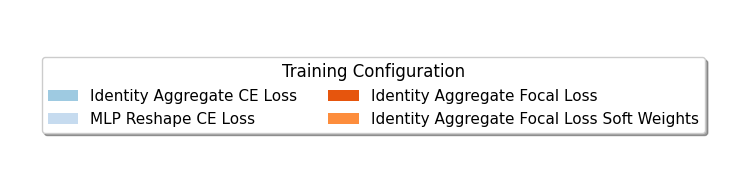

In [13]:
# Create a figure with just the legend
fig, ax = plt.subplots(figsize=(8, 2))
ax.axis('off')

# Create dummy bars just to get the legend handles
for idx, name in enumerate(df['index']):
    ax.bar(0, 0, color=custom_colors[idx], label=name)

# Create legend
legend = ax.legend(loc='center', ncol=2, fontsize=11, 
                   title='Training Configuration', title_fontsize=12,
                   frameon=True, fancybox=True, shadow=True)

plt.tight_layout()
#plt.savefig('legend_only.pdf', dpi=300, bbox_inches='tight')
#plt.savefig('legend_only.png', dpi=300, bbox_inches='tight')
plt.show()

Loss

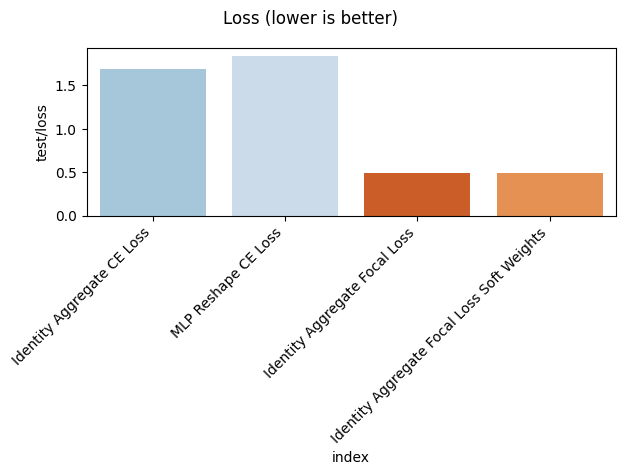

In [44]:
plt.suptitle('Loss (lower is better)')
sns.barplot(data=df, x='index', y='test/loss', hue='index', palette=custom_colors, legend=False)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Training Metrics

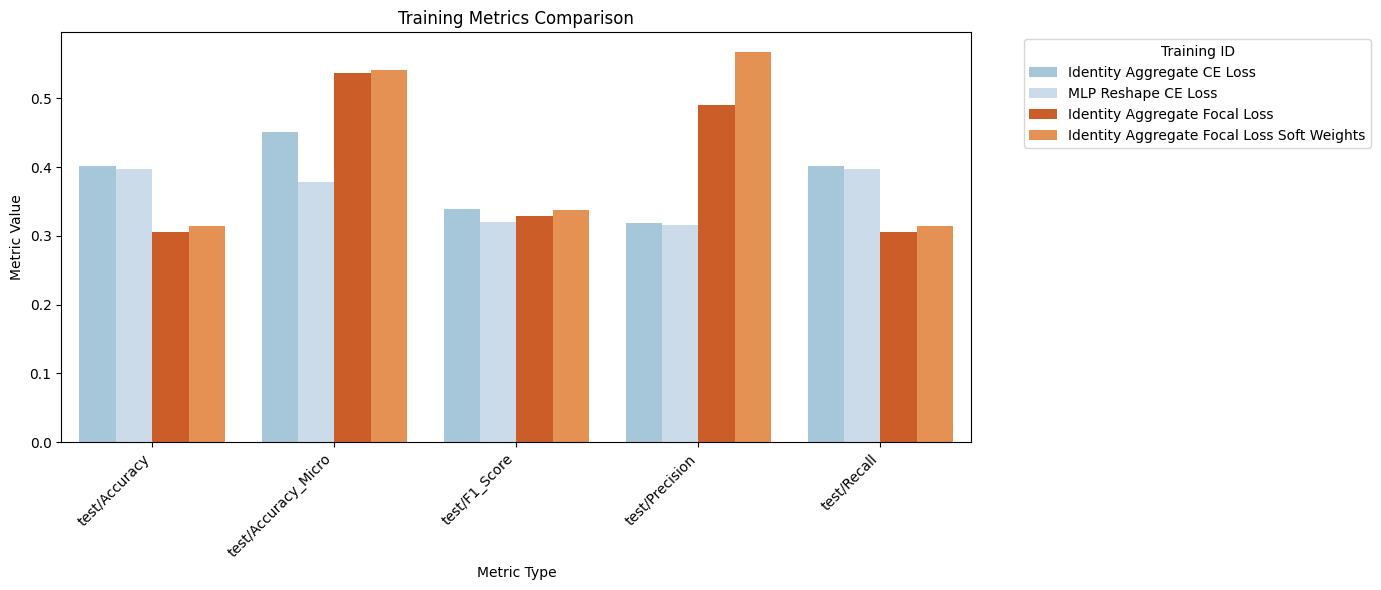

In [55]:
metrics_to_plot = [
                   'test/Accuracy',
                   'test/Accuracy_Micro',
                   'test/F1_Score',
                   'test/Precision',
                   'test/Recall'
                   ]

df_melted = df.melt(id_vars=['index'], 
                     value_vars=metrics_to_plot,
                     var_name='Metric', 
                     value_name='Value')

# Create grouped boxplot
plt.figure(figsize=(14, 6))
sns.barplot(data=df_melted, x='Metric', y='Value', hue='index',palette=custom_colors)
plt.title('Training Metrics Comparison')
plt.ylabel('Metric Value')
plt.xlabel('Metric Type')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Training ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Loss vs Accuracy

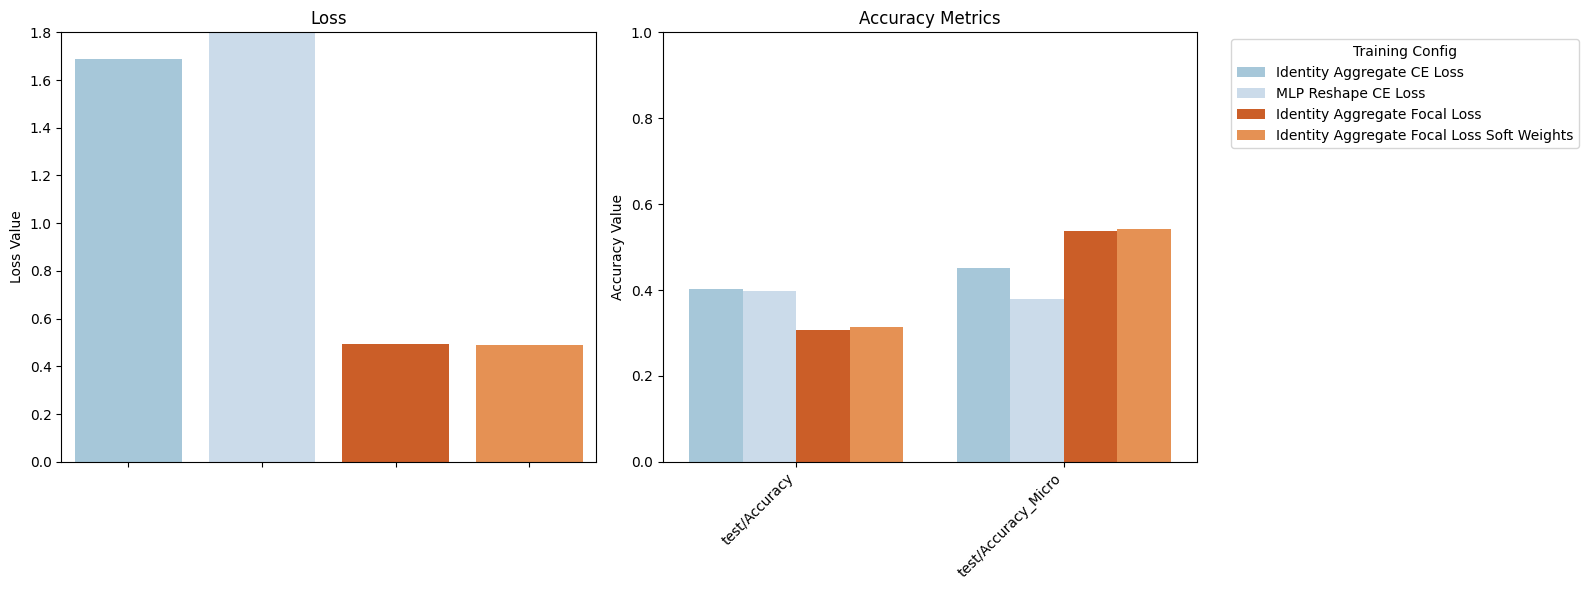

In [58]:
# Separate loss and accuracy metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Loss (0 to 1.8)
loss_data = df[['index', 'test/loss']]
sns.barplot(data=loss_data, x='index', y='test/loss', hue='index', 
            palette=custom_colors, legend=False, ax=ax1)
ax1.set_ylim(0, 1.8)
ax1.set_title('Loss')
ax1.set_ylabel('Loss Value')
ax1.set_xlabel('')
ax1.set_xticklabels([])  # Remove x-axis labels

# Plot 2: Accuracies (0 to 1)
accuracy_metrics = ['test/Accuracy', 'test/Accuracy_Micro']
df_acc = df.melt(id_vars=['index'], 
                  value_vars=accuracy_metrics,
                  var_name='Metric', 
                  value_name='Value')
sns.barplot(data=df_acc, x='Metric', y='Value', hue='index',
            palette=custom_colors, ax=ax2)
ax2.set_ylim(0, 1)
ax2.set_title('Accuracy Metrics')
ax2.set_ylabel('Accuracy Value')
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=45)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax2.legend(title='Training Config', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Accuracy by class

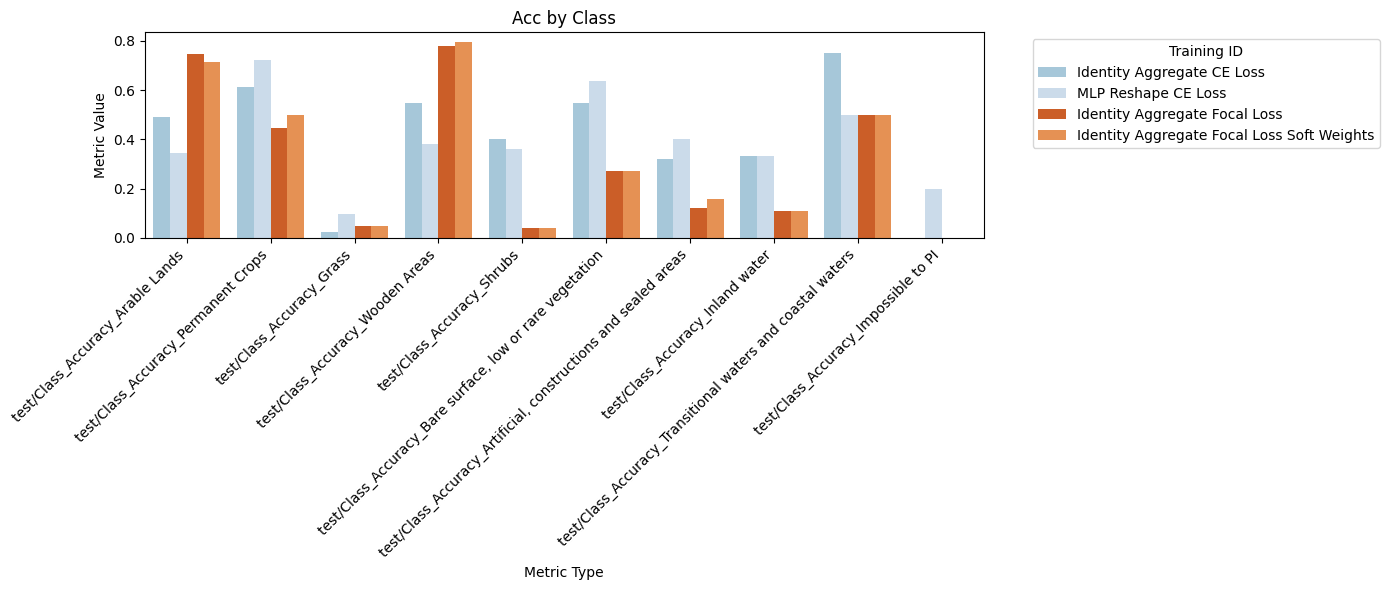

In [63]:
metrics_to_plot = ['test/Class_Accuracy_Arable Lands',
                    'test/Class_Accuracy_Permanent Crops',
                    'test/Class_Accuracy_Grass',
                    'test/Class_Accuracy_Wooden Areas',
                    'test/Class_Accuracy_Shrubs',
                    'test/Class_Accuracy_Bare surface, low or rare vegetation',
                    'test/Class_Accuracy_Artificial, constructions and sealed areas',
                    'test/Class_Accuracy_Inland water',
                    'test/Class_Accuracy_Transitional waters and coastal waters',
                    'test/Class_Accuracy_Impossible to PI',
                    ]
df_melted = df.melt(id_vars=['index'], 
                     value_vars=metrics_to_plot,
                     var_name='Metric', 
                     value_name='Value')

# Create grouped boxplot
plt.figure(figsize=(14, 6))
sns.barplot(data=df_melted, x='Metric', y='Value', hue='index',palette=custom_colors)
plt.title('Accuracy by Class')
plt.ylabel('Metric Value')
plt.xlabel('Metric Type')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Training ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

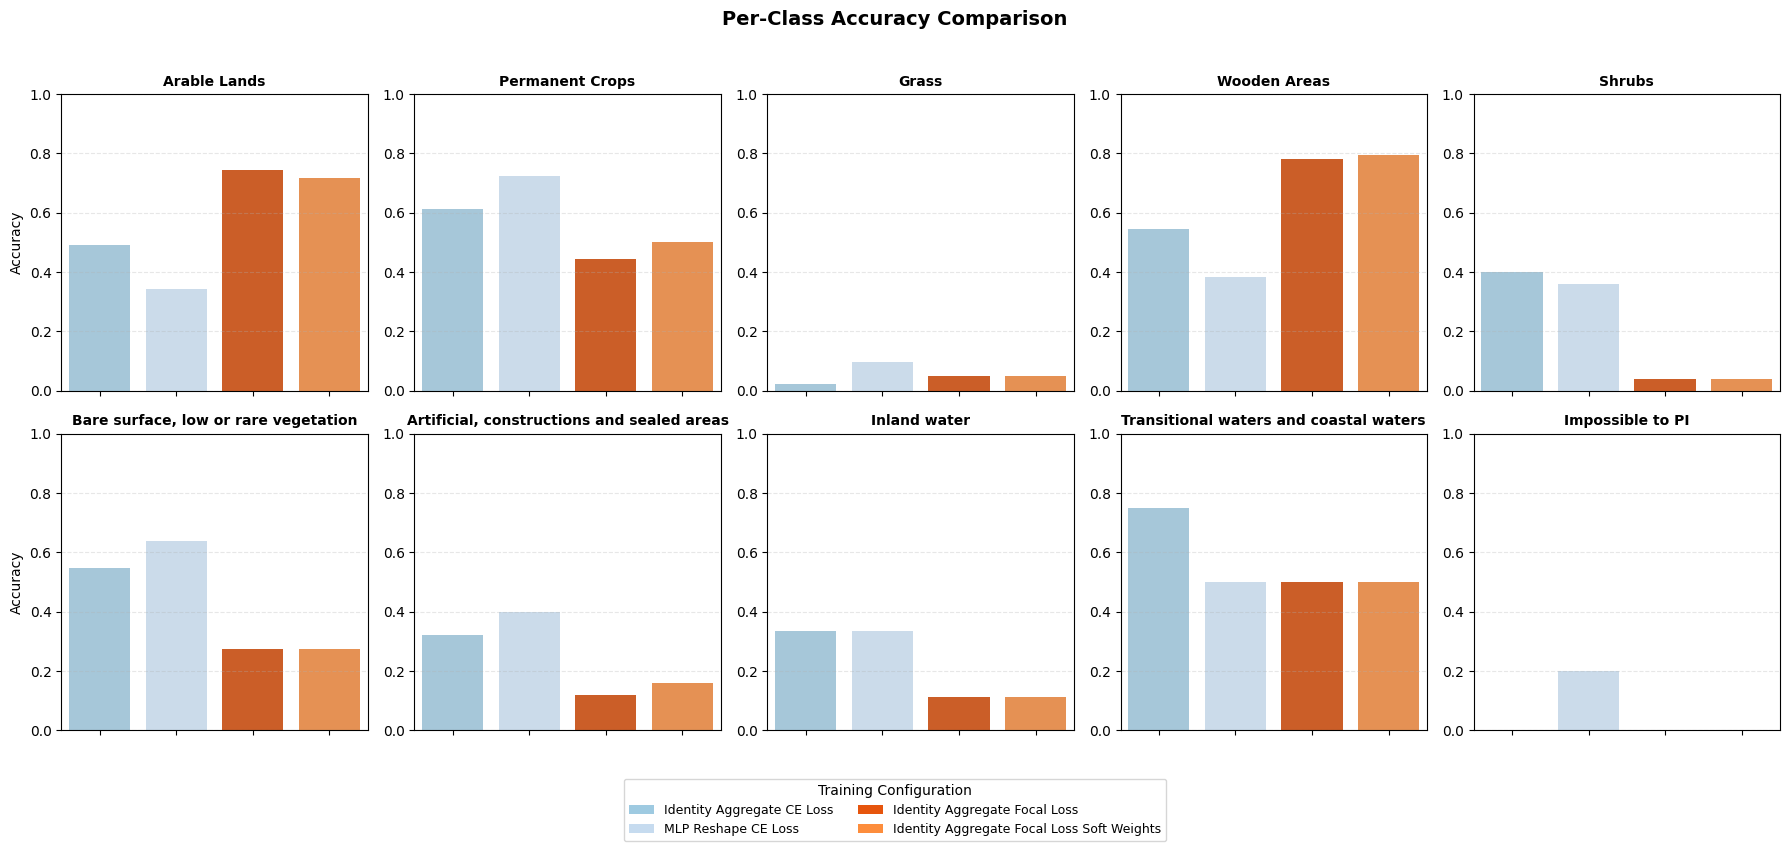

In [68]:
metrics_to_plot = ['test/Class_Accuracy_Arable Lands',
                    'test/Class_Accuracy_Permanent Crops',
                    'test/Class_Accuracy_Grass',
                    'test/Class_Accuracy_Wooden Areas',
                    'test/Class_Accuracy_Shrubs',
                    'test/Class_Accuracy_Bare surface, low or rare vegetation',
                    'test/Class_Accuracy_Artificial, constructions and sealed areas',
                    'test/Class_Accuracy_Inland water',
                    'test/Class_Accuracy_Transitional waters and coastal waters',
                    'test/Class_Accuracy_Impossible to PI',
                    ]

# Clean category names for display
clean_names = [m.replace('test/Class_Accuracy_', '') for m in metrics_to_plot]

# Create subplots grid (2 rows x 5 columns)
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

# Create custom legend handles
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=custom_colors[i], label=df['index'].iloc[i]) 
                  for i in range(len(df))]

for idx, (metric, name) in enumerate(zip(metrics_to_plot, clean_names)):
    ax = axes[idx]
    metric_data = df[['index', metric]].copy()
    
    sns.barplot(data=metric_data, x='index', y=metric, hue='index',
                palette=custom_colors, legend=False, ax=ax)
    
    ax.set_ylim(0, 1)
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_ylabel('Accuracy' if idx % 5 == 0 else '')
    ax.set_xlabel('')
    ax.set_xticklabels([])
    ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add legend with custom handles
fig.legend(handles=legend_handles, title='Training Configuration', 
          loc='center', bbox_to_anchor=(0.5, -0.02), ncol=2, fontsize=9)

plt.suptitle('Per-Class Accuracy Comparison', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.show()

F1 by class

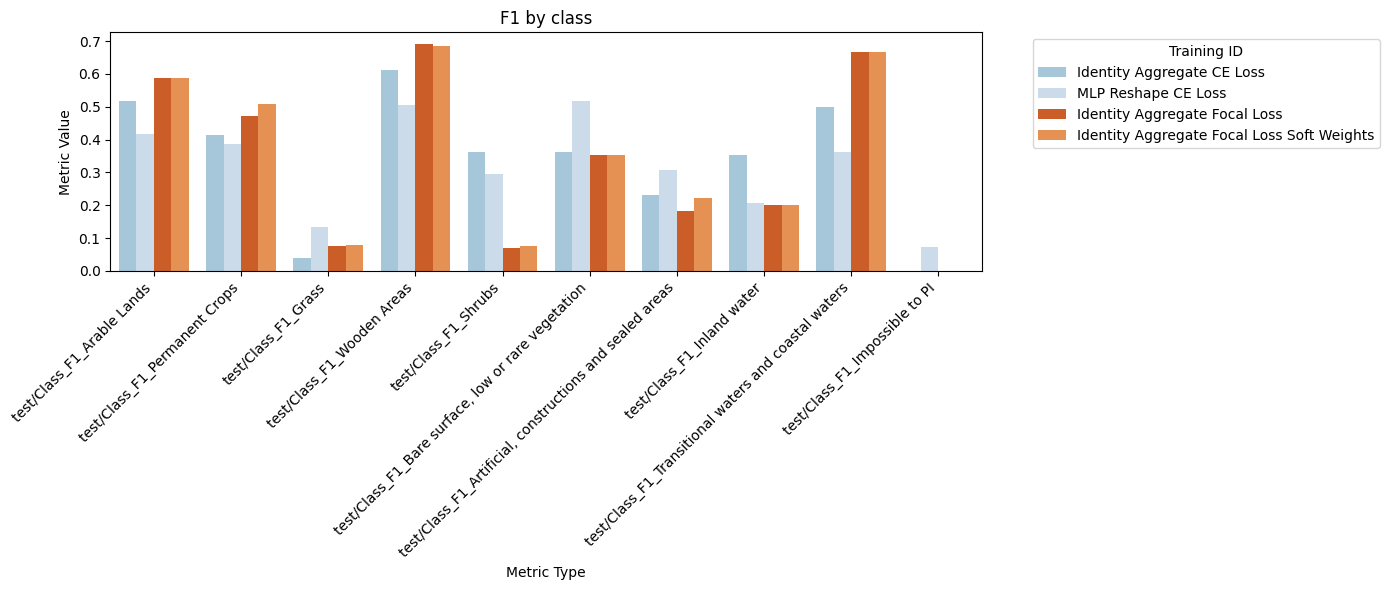

In [49]:

metrics_to_plot = [ 'test/Class_F1_Arable Lands',
                    'test/Class_F1_Permanent Crops',
                    'test/Class_F1_Grass',
                    'test/Class_F1_Wooden Areas',
                    'test/Class_F1_Shrubs',
                    'test/Class_F1_Bare surface, low or rare vegetation',
                    'test/Class_F1_Artificial, constructions and sealed areas',
                    'test/Class_F1_Inland water',
                    'test/Class_F1_Transitional waters and coastal waters',
                    'test/Class_F1_Impossible to PI',
                    ]
df_melted = df.melt(id_vars=['index'], 
                     value_vars=metrics_to_plot,
                     var_name='Metric', 
                     value_name='Value')

# Create grouped boxplot
plt.figure(figsize=(14, 6))
sns.barplot(data=df_melted, x='Metric', y='Value', hue='index',palette=custom_colors)
plt.title('F1 by class')
plt.ylabel('Metric Value')
plt.xlabel('Metric Type')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Training ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Spider Accuracy

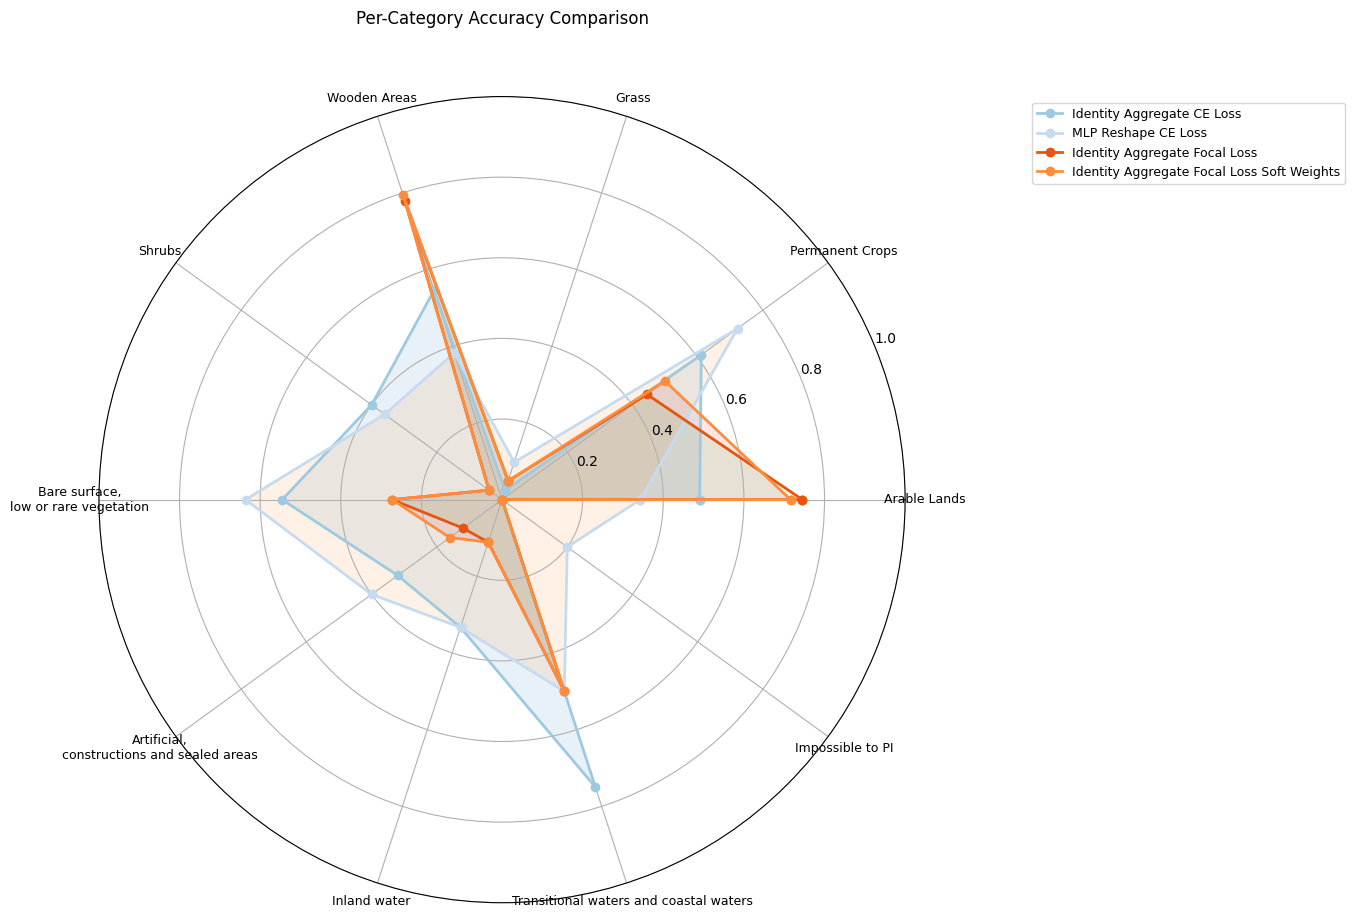

In [59]:
from math import pi

# Spider chart for category-level performance
categories = ['test/Class_Accuracy_Arable Lands',
                    'test/Class_Accuracy_Permanent Crops',
                    'test/Class_Accuracy_Grass',
                    'test/Class_Accuracy_Wooden Areas',
                    'test/Class_Accuracy_Shrubs',
                    'test/Class_Accuracy_Bare surface, low or rare vegetation',
                    'test/Class_Accuracy_Artificial, constructions and sealed areas',
                    'test/Class_Accuracy_Inland water',
                    'test/Class_Accuracy_Transitional waters and coastal waters',
                    'test/Class_Accuracy_Impossible to PI',
                    ]

N = len(categories)

fig, ax = plt.subplots(figsize=(12, 10), subplot_kw=dict(projection='polar'))

colors = sns.color_palette(custom_colors, len(df))

for idx, row in df.iterrows():
    values = [row[cat] for cat in categories]
    values += values[:1]  # Close the plot
    
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, label=row['index'], color=colors[idx])
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
# Wrap long category names
wrapped_labels = [cat.replace('test/Class_Accuracy_', '').replace(', ', ',\n') for cat in categories]
ax.set_xticklabels(wrapped_labels, size=9)
ax.set_ylim(0, 1)  # Assuming scores are 0-1
ax.legend(loc='upper left', bbox_to_anchor=(1.15, 1.0), fontsize=9, frameon=True)
plt.title('Per-Category Accuracy Comparison', y=1.08, fontsize=12)
plt.tight_layout()
plt.show()

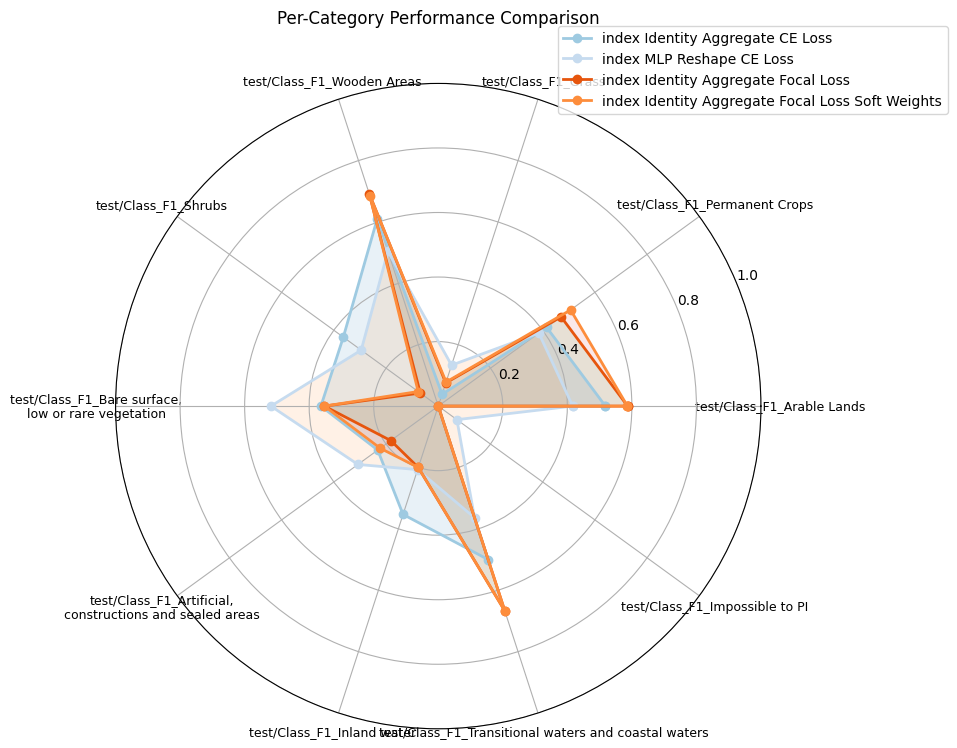

In [54]:
from math import pi

# Spider chart for category-level performance
categories = [ 'test/Class_F1_Arable Lands',
                    'test/Class_F1_Permanent Crops',
                    'test/Class_F1_Grass',
                    'test/Class_F1_Wooden Areas',
                    'test/Class_F1_Shrubs',
                    'test/Class_F1_Bare surface, low or rare vegetation',
                    'test/Class_F1_Artificial, constructions and sealed areas',
                    'test/Class_F1_Inland water',
                    'test/Class_F1_Transitional waters and coastal waters',
                    'test/Class_F1_Impossible to PI',
                    ]

N = len(categories)

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

colors = sns.color_palette(custom_colors, len(df))

for idx, row in df.iterrows():
    values = [row[cat] for cat in categories]
    values += values[:1]  # Close the plot
    
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, label=f"index {row['index']}", color=colors[idx])
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
# Wrap long category names
wrapped_labels = [cat.replace(', ', ',\n') for cat in categories]
ax.set_xticklabels(wrapped_labels, size=9)
ax.set_ylim(0, 1)  # Assuming scores are 0-1
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.title('Per-Category Performance Comparison', y=1.08)
plt.tight_layout()
plt.show()